<a href="https://colab.research.google.com/github/WooSeungJi/WM811K-Project/blob/main/Ram_%EC%A0%88%EC%95%BD_WM_811K_Wafer_Map.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# ============================================================
# WM-811K Wafer Map Defect Classification
# RAM 부족 해결 버전 전체 코드
# ============================================================
#
# 핵심 변경점
# 1. 전체 waferMap 이미지를 한 번에 X 배열로 만들지 않음
# 2. none 클래스는 너무 많기 때문에 다운샘플링
# 3. tf.data.Dataset.from_generator()를 사용해서 배치 단위로 처리
# 4. float32 사용
# 5. 불필요한 DataFrame은 중간중간 삭제해서 RAM 확보
#
# ============================================================


# ============================================================
# 0. 라이브러리 불러오기
# ============================================================

import os
import gc
import sys
import pickle
import random
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, recall_score

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau


# ============================================================
# 1. 기본 설정
# ============================================================

RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

IMG_SIZE = 64
BATCH_SIZE = 64

# none 클래스가 너무 많기 때문에 처음에는 15000개만 사용
# RAM이 부족하면 8000 또는 10000으로 줄이면 됨
NONE_LIMIT = 15000

# 학습 epoch
EPOCHS = 30


# ============================================================
# 2. Google Drive 연결
# ============================================================

drive.mount("/content/drive")


# ============================================================
# 3. 데이터 경로 설정
# ============================================================

DATA_PATH = "/content/drive/MyDrive/ML Project/WM811K/LSWMD.pkl"
OUTPUT_DIR = "/content/drive/MyDrive/ML Project/WM811K/outputs"

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("파일 존재 여부:", os.path.exists(DATA_PATH))
print("데이터 경로:", DATA_PATH)
print("결과 저장 폴더:", OUTPUT_DIR)

Mounted at /content/drive
파일 존재 여부: True
데이터 경로: /content/drive/MyDrive/ML Project/WM811K/LSWMD.pkl
결과 저장 폴더: /content/drive/MyDrive/ML Project/WM811K/outputs


In [4]:
# ============================================================
# 4. WM-811K pickle 파일 안전 로드 함수
# ============================================================

def load_wm811k_pickle(path):
    """
    WM-811K의 LSWMD.pkl 파일은 예전 pandas 버전에서 저장된 pickle인 경우가 많다.

    그래서 최신 pandas에서 바로 pd.read_pickle(path)를 하면
    ModuleNotFoundError: No module named 'pandas.indexes'
    같은 오류가 발생할 수 있다.

    이 함수는 pandas.indexes 관련 모듈 이름을 최신 pandas 구조에 맞게 임시 연결한 뒤,
    pickle 파일을 최대한 안전하게 불러온다.
    """

    try:
        import pandas.core.indexes.base
        import pandas.core.indexes.numeric
        import pandas.core.indexes.datetimes
        import pandas.core.indexes.timedeltas
        import pandas.core.indexes.period
        import pandas.core.indexes.multi

        sys.modules["pandas.indexes"] = pd.core.indexes
        sys.modules["pandas.indexes.base"] = pandas.core.indexes.base
        sys.modules["pandas.indexes.numeric"] = pandas.core.indexes.numeric
        sys.modules["pandas.indexes.datetimes"] = pandas.core.indexes.datetimes
        sys.modules["pandas.indexes.timedeltas"] = pandas.core.indexes.timedeltas
        sys.modules["pandas.indexes.period"] = pandas.core.indexes.period
        sys.modules["pandas.indexes.multi"] = pandas.core.indexes.multi

    except Exception as e:
        print("pandas 호환 alias 설정 중 경고:", e)

    try:
        df = pd.read_pickle(path)
        print("pd.read_pickle로 로드 성공")
        return df

    except Exception as e1:
        print("pd.read_pickle 실패:", e1)
        print("pickle.load encoding='latin1' 방식으로 재시도")

    with open(path, "rb") as f:
        df = pickle.load(f, encoding="latin1")

    print("pickle.load로 로드 성공")
    return df


In [5]:
# ============================================================
# 5. 데이터 로드
# ============================================================

df = load_wm811k_pickle(DATA_PATH)

print()
print("전체 데이터 shape:", df.shape)
print()
print("컬럼 목록:")
print(df.columns)

pandas 호환 alias 설정 중 경고: No module named 'pandas.core.indexes.numeric'
pd.read_pickle로 로드 성공

전체 데이터 shape: (811457, 6)

컬럼 목록:
Index(['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trianTestLabel',
       'failureType'],
      dtype='object')


In [6]:
# ============================================================
# 6. failureType에서 실제 label 추출
# ============================================================

def extract_label(x):
    """
    WM-811K의 failureType은 보통 [[none]], [[Center]] 같은 구조로 들어 있다.
    따라서 x[0][0]을 꺼내면 실제 라벨명이 나온다.
    """

    try:
        label = x[0][0]

        if label == "":
            return "unknown"

        return label

    except:
        return "unknown"


df["label"] = df["failureType"].apply(extract_label)

print()
print("전체 label 분포:")
print(df["label"].value_counts(dropna=False))


전체 label 분포:
label
unknown      638507
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64


In [7]:
# ============================================================
# 7. unknown 제거
# ============================================================

df_labeled = df[df["label"] != "unknown"].copy()

print()
print("라벨링된 데이터 개수:", len(df_labeled))
print()
print("라벨링된 데이터 클래스 분포:")
print(df_labeled["label"].value_counts())


라벨링된 데이터 개수: 172950

라벨링된 데이터 클래스 분포:
label
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64


In [8]:
# ============================================================
# 8. 원본 df 삭제해서 RAM 확보
# ============================================================

del df
gc.collect()

print()
print("불필요한 원본 df 삭제 완료")



불필요한 원본 df 삭제 완료


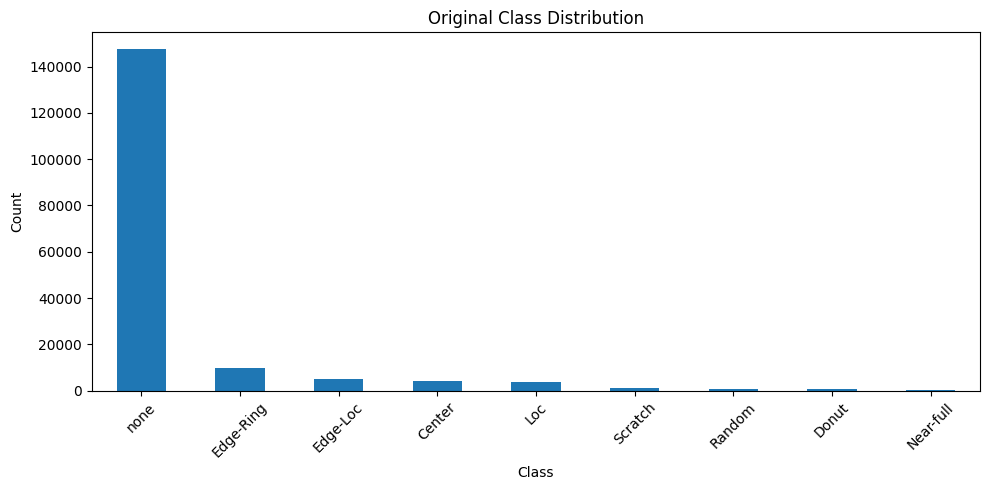

In [9]:
# ============================================================
# 9. 클래스 분포 시각화
# ============================================================

label_counts = df_labeled["label"].value_counts()

plt.figure(figsize=(10, 5))
label_counts.plot(kind="bar")
plt.title("Original Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


샘플링 후 데이터 개수: 40519

샘플링 후 클래스 분포:
label
none         15000
Edge-Ring     9680
Edge-Loc      5189
Center        4294
Loc           3593
Scratch       1193
Random         866
Donut          555
Near-full      149
Name: count, dtype: int64

샘플링 이후 불필요한 데이터 삭제 완료


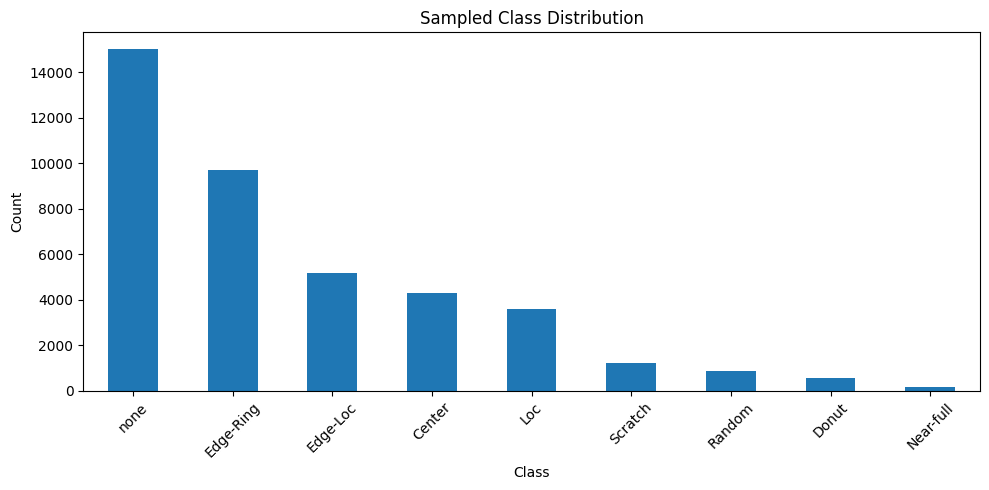


클래스 이름:
[np.str_('Center'), np.str_('Donut'), np.str_('Edge-Loc'), np.str_('Edge-Ring'), np.str_('Loc'), np.str_('Near-full'), np.str_('Random'), np.str_('Scratch'), np.str_('none')]

클래스 개수: 9

라벨 인코딩 매핑:
0 -> Center
1 -> Donut
2 -> Edge-Loc
3 -> Edge-Ring
4 -> Loc
5 -> Near-full
6 -> Random
7 -> Scratch
8 -> none

train 개수: 32415
validation 개수: 4052
test 개수: 4052


In [10]:
# ============================================================
# 10. none 클래스 다운샘플링 + defect 클래스 전체 사용
# ============================================================

df_none = df_labeled[df_labeled["label"] == "none"]
df_defect = df_labeled[df_labeled["label"] != "none"]

df_none_sampled = df_none.sample(
    n=min(NONE_LIMIT, len(df_none)),
    random_state=RANDOM_STATE
)

df_sampled = pd.concat([df_none_sampled, df_defect], axis=0)
df_sampled = df_sampled.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print()
print("샘플링 후 데이터 개수:", len(df_sampled))
print()
print("샘플링 후 클래스 분포:")
print(df_sampled["label"].value_counts())


# ============================================================
# 11. 불필요한 DataFrame 삭제해서 RAM 확보
# ============================================================

del df_labeled
del df_none
del df_defect
del df_none_sampled

gc.collect()

print()
print("샘플링 이후 불필요한 데이터 삭제 완료")


# ============================================================
# 12. 샘플링 후 클래스 분포 시각화
# ============================================================

sampled_label_counts = df_sampled["label"].value_counts()

plt.figure(figsize=(10, 5))
sampled_label_counts.plot(kind="bar")
plt.title("Sampled Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ============================================================
# 13. 라벨 인코딩
# ============================================================

label_encoder = LabelEncoder()

df_sampled["label_encoded"] = label_encoder.fit_transform(df_sampled["label"])

class_names = list(label_encoder.classes_)
num_classes = len(class_names)

print()
print("클래스 이름:")
print(class_names)

print()
print("클래스 개수:", num_classes)

print()
print("라벨 인코딩 매핑:")
for i, name in enumerate(class_names):
    print(i, "->", name)


# ============================================================
# 14. train / validation / test 분리
# ============================================================

indices = np.arange(len(df_sampled))
labels_encoded = df_sampled["label_encoded"].values

train_idx, temp_idx, y_train, y_temp = train_test_split(
    indices,
    labels_encoded,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=labels_encoded
)

val_idx, test_idx, y_val, y_test = train_test_split(
    temp_idx,
    y_temp,
    test_size=0.5,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print()
print("train 개수:", len(train_idx))
print("validation 개수:", len(val_idx))
print("test 개수:", len(test_idx))



#**여기서 부터 CNN 학습용 코드임**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
파일 존재 여부: True
데이터 경로: /content/drive/MyDrive/ML Project/WM811K/LSWMD.pkl
결과 저장 폴더: /content/drive/MyDrive/ML Project/WM811K/outputs
pandas 호환 alias 설정 중 경고: No module named 'pandas.core.indexes.numeric'
pd.read_pickle로 로드 성공

전체 데이터 shape: (811457, 6)

컬럼 목록:
Index(['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trianTestLabel',
       'failureType'],
      dtype='object')

전체 label 분포:
label
unknown      638507
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64

라벨링된 데이터 개수: 172950

라벨링된 데이터 클래스 분포:
label
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: i

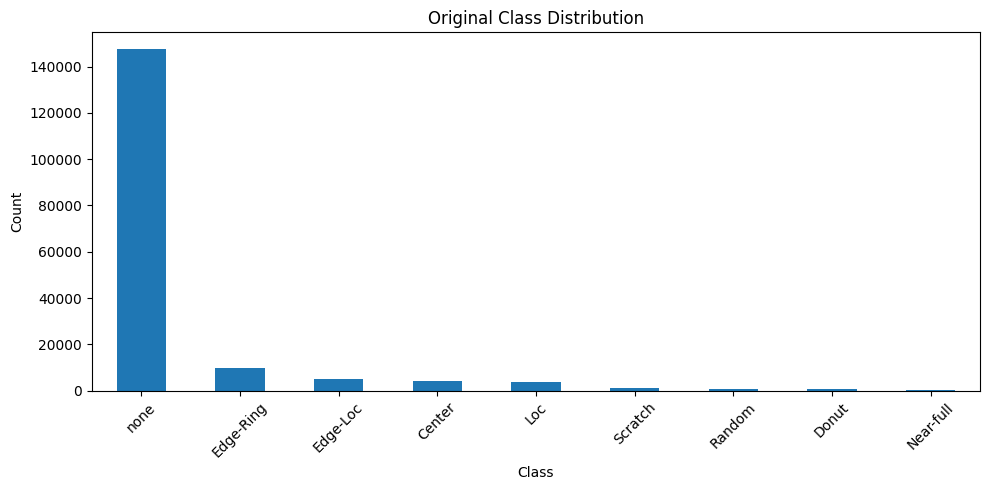


샘플링 후 데이터 개수: 40519

샘플링 후 클래스 분포:
label
none         15000
Edge-Ring     9680
Edge-Loc      5189
Center        4294
Loc           3593
Scratch       1193
Random         866
Donut          555
Near-full      149
Name: count, dtype: int64

샘플링 이후 불필요한 데이터 삭제 완료


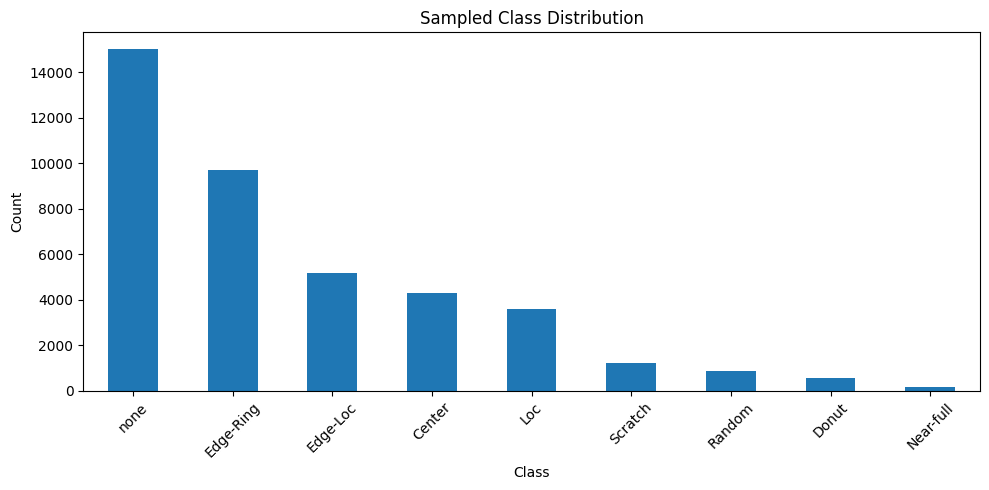


클래스 이름:
[np.str_('Center'), np.str_('Donut'), np.str_('Edge-Loc'), np.str_('Edge-Ring'), np.str_('Loc'), np.str_('Near-full'), np.str_('Random'), np.str_('Scratch'), np.str_('none')]

클래스 개수: 9

라벨 인코딩 매핑:
0 -> Center
1 -> Donut
2 -> Edge-Loc
3 -> Edge-Ring
4 -> Loc
5 -> Near-full
6 -> Random
7 -> Scratch
8 -> none

train 개수: 32415
validation 개수: 4052
test 개수: 4052

tf.data Dataset 생성 완료


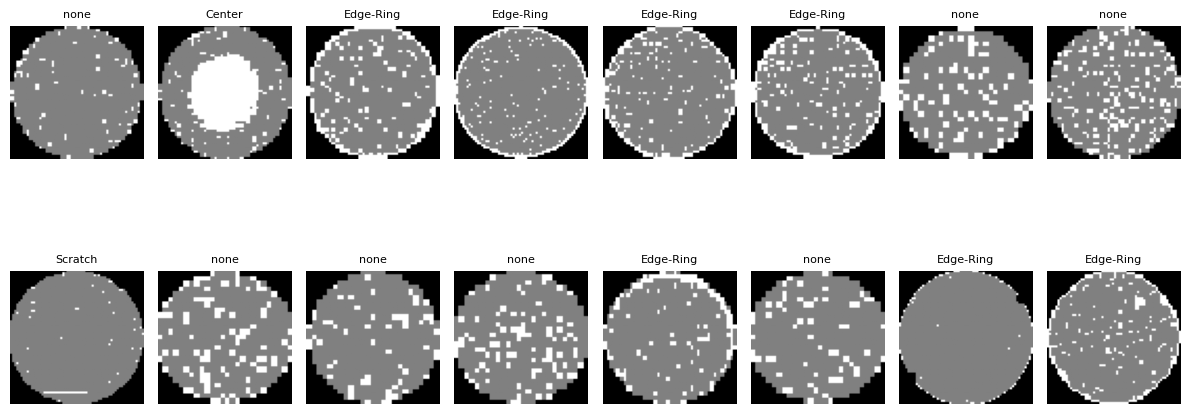


class_weight:
{0: 1.0485201358563805, 1: 8.111861861861861, 2: 0.867662410664097, 3: 0.4650912534435262, 4: 1.2531895151936905, 5: 30.26610644257703, 6: 5.197210197210198, 7: 3.7713787085514836, 8: 0.3001388888888889}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,241 (434.54 KB)

 Trainable params: 110,793 (432.79 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/30
507/507 ━━━━━━━━━━━━━━━━━━━━ 84s 136ms/step - accuracy: 0.5804 - loss: 1.1297 - val_accuracy: 0.1431 - val_loss: 3.8546 - learning_rate: 0.0010
Epoch 2/30
507/507 ━━━━━━━━━━━━━━━━━━━━ 67s 127ms/step - accuracy: 0.7160 - loss: 0.7853 - val_accuracy: 0.6730 - val_loss: 0.8236 - learning_rate: 0.0010
Epoch 3/30
507/507 ━━━━━━━━━━━━━━━━━━━━ 82s 155ms/step - accuracy: 0.7688 - loss: 0.6579 - val_accuracy: 0.8055 - val_loss: 0.5616 - learning_rate: 0.0010
Epoch 4/30
507/507 ━━━━━━━━━━━━━━━━━━━━ 68s 126ms/step - accuracy: 0.8128 - loss: 0.5401 - val_accuracy: 0.7957 - val_loss: 0.6449 - learning_rate: 0.0010
Epoch 5/30
507/507 ━━━━━━━━━━━━━━━━━━━━ 68s 128ms/step - accuracy: 0.8299 - loss: 0.4813 - val_accuracy: 0.8122 - val_loss: 0.6341 - learning_rate: 0.0010
Epoch 6/30
507/507 ━━━━━━━━━━━━━━━━━━━━ 67s 126ms/step - accuracy: 0.8662 - loss: 0.3814 - val_accuracy: 0.8685 - val_loss: 0.3812 - learning_rate: 5.0000e-04
Epoch 7/30
507/507 ━━━━━━━━━━━━━━━━━━━━ 66s 124ms/step - accuracy:

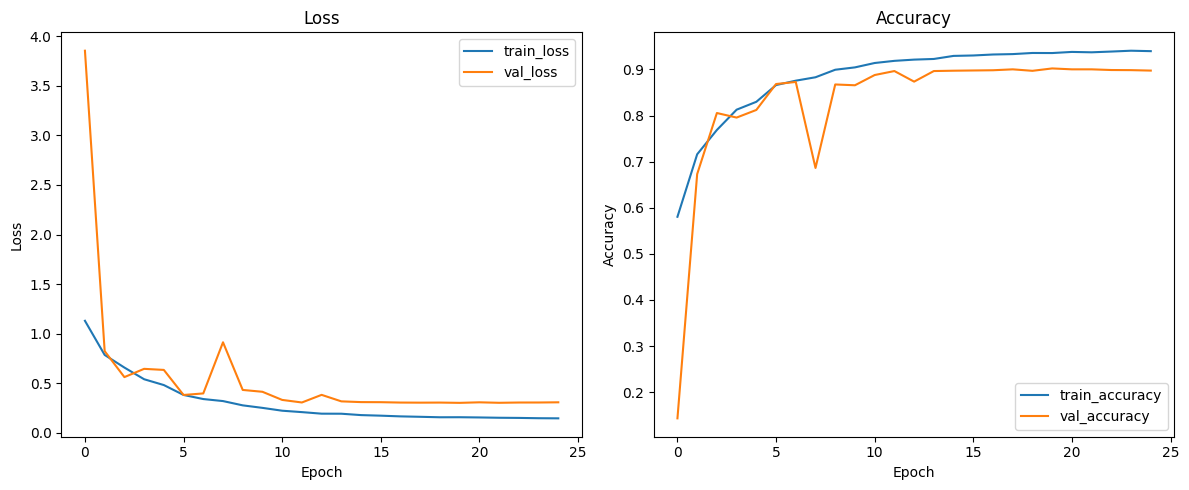

64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 107ms/step - accuracy: 0.9099 - loss: 0.2753

Test Loss: 0.27532196044921875
Test Accuracy: 0.9099210500717163


AxisError: axis 1 is out of bounds for array of dimension 1

In [ ]:
# ============================================================
# 15. waferMap 전처리 함수
# ============================================================

def resize_wafer_map(wafer_map, img_size=IMG_SIZE):
    """
    wafer_map 하나를 CNN 입력 형태로 바꾼다.

    원본 wafer map 값:
    0: wafer 바깥 또는 빈 영역
    1: 정상 die
    2: 불량 die

    처리 과정:
    1. numpy array로 변환
    2. channel 차원 추가
    3. TensorFlow resize 사용
    4. 0~2 값을 0~1 범위로 정규화
    """

    wafer_map = np.array(wafer_map, dtype=np.float32)

    wafer_map = np.expand_dims(wafer_map, axis=-1)

    wafer_map = tf.image.resize(
        wafer_map,
        size=(img_size, img_size),
        method="nearest"
    )

    wafer_map = wafer_map / 2.0

    return wafer_map


# ============================================================
# 16. generator 함수
# ============================================================

def wafer_generator(index_array):
    """
    index_array에 들어 있는 index를 하나씩 읽으면서
    waferMap과 label을 생성한다.

    중요한 점:
    X 전체 배열을 미리 만들지 않는다.
    필요할 때마다 하나씩 꺼내서 처리한다.
    """

    for idx in index_array:
        wafer_map = df_sampled.loc[idx, "waferMap"]
        label = df_sampled.loc[idx, "label_encoded"]

        image = resize_wafer_map(wafer_map)

        yield image, np.int32(label)


# ============================================================
# 17. tf.data Dataset 생성 함수
# ============================================================

def make_dataset(index_array, shuffle=False):
    """
    TensorFlow Dataset을 만든다.

    shuffle=True이면 학습 데이터처럼 섞어서 사용한다.
    validation/test는 shuffle=False로 둔다.
    """

    dataset = tf.data.Dataset.from_generator(
        lambda: wafer_generator(index_array),
        output_signature=(
            tf.TensorSpec(shape=(IMG_SIZE, IMG_SIZE, 1), dtype=tf.float32),
            tf.TensorSpec(shape=(), dtype=tf.int32)
        )
    )

    if shuffle:
        dataset = dataset.shuffle(buffer_size=2048, seed=RANDOM_STATE)

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset


train_ds = make_dataset(train_idx, shuffle=True)
val_ds = make_dataset(val_idx, shuffle=False)
test_ds = make_dataset(test_idx, shuffle=False)

print()
print("tf.data Dataset 생성 완료")


# ============================================================
# 18. 샘플 이미지 확인
# ============================================================

plt.figure(figsize=(12, 6))

sample_batch = next(iter(train_ds))
sample_images, sample_labels = sample_batch

for i in range(16):
    plt.subplot(2, 8, i + 1)
    plt.imshow(sample_images[i].numpy().squeeze(), cmap="gray")
    plt.title(class_names[int(sample_labels[i])], fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()


# ============================================================
# 19. class weight 계산
# ============================================================

train_labels = df_sampled.loc[train_idx, "label_encoded"].values

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weight_dict = {
    int(class_id): float(weight)
    for class_id, weight in zip(np.unique(train_labels), class_weights_array)
}

print()
print("class_weight:")
print(class_weight_dict)





In [ ]:

# ============================================================
# 20. CNN 모델 생성 함수
# ============================================================

def build_light_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 1), num_classes=num_classes):
    """
    RAM과 GPU 메모리를 너무 많이 쓰지 않는 가벼운 CNN 모델이다.

    처음부터 큰 모델을 쓰면 Colab에서 또 터질 수 있으므로,
    Conv2D 필터 수를 32 -> 64 -> 128 정도로 제한한다.
    """

    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.GlobalAveragePooling2D(),

        layers.Dense(128, activation="relu"),
        layers.Dropout(0.4),

        layers.Dense(num_classes, activation="softmax")
    ])

    return model


# ============================================================
# 21. 모델 생성 및 컴파일
# ============================================================

model = build_light_cnn()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


# ============================================================
# 22. callback 설정
# ============================================================

best_model_path = os.path.join(OUTPUT_DIR, "best_light_cnn.keras")

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    ModelCheckpoint(
        filepath=best_model_path,
        monitor="val_loss",
        save_best_only=True
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    )
]


# ============================================================
# 23. 모델 학습
# ============================================================

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=callbacks
)


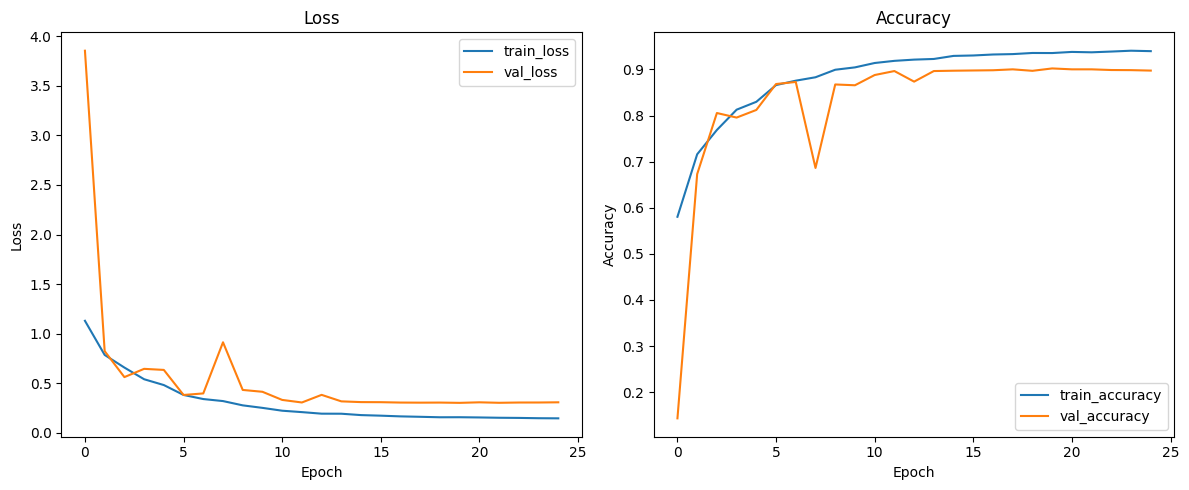

64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 138ms/step - accuracy: 0.9099 - loss: 0.2753

Test Loss: 0.27532196044921875
Test Accuracy: 0.9099210500717163
예측 완료
y_true shape: (4052,)
y_pred shape: (4052,)

Accuracy: 0.9099210266535045
Balanced Accuracy: 0.8844715634461152
Macro F1-score: 0.8663047054073619
Weighted F1-score: 0.910084973300348
Macro Recall: 0.8844715634461152

Classification Report:
              precision    recall  f1-score   support

      Center     0.9109    0.8558    0.8825       430
       Donut     0.7273    0.8727    0.7934        55
    Edge-Loc     0.8577    0.8709    0.8642       519
   Edge-Ring     0.9906    0.9752    0.9828       968
         Loc     0.7309    0.7167    0.7237       360
   Near-full     0.8824    1.0000    0.9375        15
      Random     0.8681    0.9186    0.8927        86
     Scratch     0.7480    0.7983    0.7724       119
        none     0.9432    0.9520    0.9476      1500

    accuracy                         0.9099      4052
   macro avg    

<Figure size 1000x1000 with 0 Axes>

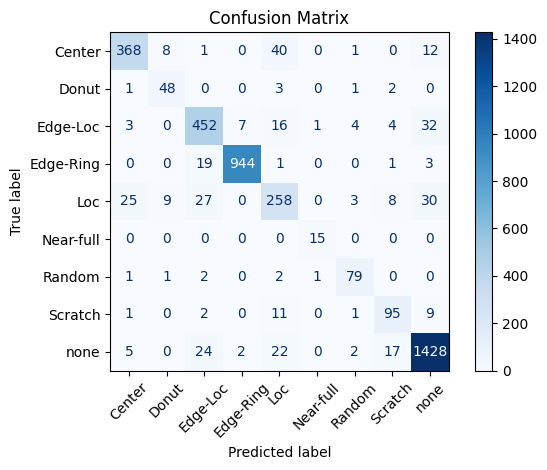


결과 저장 완료:
/content/drive/MyDrive/ML Project/WM811K/outputs/light_cnn_result.csv

모델 저장 완료:
/content/drive/MyDrive/ML Project/WM811K/outputs/final_light_cnn.keras

전체 코드 실행 완료


In [ ]:
# ============================================================
# 24. 학습 곡선 시각화
# ============================================================

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="train_accuracy")
plt.plot(history.history["val_accuracy"], label="val_accuracy")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 25. test 데이터 평가
# ============================================================

test_loss, test_acc = model.evaluate(test_ds)

print()
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)


# ============================================================
# 26. y_true, y_pred 생성
# ============================================================

# y_true, y_pred 생성

# ============================================================
# y_true, y_pred 생성
# ============================================================

y_true = []
y_pred = []

for batch_images, batch_labels in test_ds:
    pred_probs = model.predict(batch_images, verbose=0)

    pred_probs = np.array(pred_probs)

    pred_labels = np.argmax(pred_probs, axis=-1)

    y_true.extend(batch_labels.numpy().reshape(-1))

    if np.ndim(pred_labels) == 0:
        y_pred.append(pred_labels.item())
    else:
        y_pred.extend(pred_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("예측 완료")
print("y_true shape:", y_true.shape)
print("y_pred shape:", y_pred.shape)


# ============================================================
# 27. 성능 지표 출력
# ============================================================

acc = accuracy_score(y_true, y_pred)
balanced_acc = balanced_accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average="macro")
weighted_f1 = f1_score(y_true, y_pred, average="weighted")
macro_recall = recall_score(y_true, y_pred, average="macro")

print()
print("Accuracy:", acc)
print("Balanced Accuracy:", balanced_acc)
print("Macro F1-score:", macro_f1)
print("Weighted F1-score:", weighted_f1)
print("Macro Recall:", macro_recall)

print()
print("Classification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
))


# ============================================================
# 28. Confusion Matrix 출력
# ============================================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    xticks_rotation=45,
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


# ============================================================
# 29. 결과 저장
# ============================================================

result_dict = {
    "model": "Light CNN with tf.data generator",
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "none_limit": NONE_LIMIT,
    "num_classes": num_classes,
    "class_names": class_names,
    "test_accuracy": acc,
    "balanced_accuracy": balanced_acc,
    "macro_f1": macro_f1,
    "weighted_f1": weighted_f1,
    "macro_recall": macro_recall
}

result_df = pd.DataFrame([result_dict])

result_csv_path = os.path.join(OUTPUT_DIR, "light_cnn_result.csv")
result_df.to_csv(result_csv_path, index=False, encoding="utf-8-sig")

print()
print("결과 저장 완료:")
print(result_csv_path)


# ============================================================
# 30. 모델 저장
# ============================================================

final_model_path = os.path.join(OUTPUT_DIR, "final_light_cnn.keras")
model.save(final_model_path)

print()
print("모델 저장 완료:")
print(final_model_path)


# ============================================================
# 31. 마무리 RAM 정리
# ============================================================

gc.collect()

print()
print("전체 코드 실행 완료")

현재 코드가 하는 일 (요약)
1. 데이터 불러오기
WM-811K 데이터셋(LSWMD.pkl) 로드
failureType에서 실제 결함 라벨 추출
2. 클래스 불균형 완화

현재는 데이터 증강을 하지 않음

대신 두 가지 방법 사용

(1) Down Sampling

none 클래스가 너무 많아서 최대 15,000개만 사용

(2) Class Weight

샘플 수가 적은 클래스에 더 큰 가중치 부여
Scratch, Donut 같은 희소 클래스 학습 강화
3. 메모리 최적화

Google Colab RAM 부족 문제 해결을 위해

전체 이미지를 한 번에 메모리에 올리지 않음
tf.data.Dataset.from_generator() 사용
불필요한 데이터 삭제
float32 사용
4. CNN 입력 생성

웨이퍼 맵을

원본 크기
↓
64×64 이미지
↓
0~1 정규화

로 변환

5. CNN 모델 학습

간단한 CNN 사용

Conv(32)
↓
Conv(64)
↓
Conv(128)
↓
Dense
↓
Softmax
6. 성능 평가

다음 지표 계산

Accuracy
Balanced Accuracy
Macro F1
Recall
Confusion Matrix

# **이제 Feature Engineering 실험**

In [11]:
# ============================================================
# 20. Feature Engineering용 라이브러리 추가
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
from scipy.ndimage import label as connected_component_label
import joblib

In [12]:
# ============================================================
# 21. Feature Engineering 결과 저장 경로 설정
# ============================================================

FEATURE_CSV_PATH = os.path.join(OUTPUT_DIR, "wm811k_feature_table.csv")
FEATURE_PKL_PATH = os.path.join(OUTPUT_DIR, "wm811k_feature_table.pkl")

RF_MODEL_PATH = os.path.join(OUTPUT_DIR, "feature_engineering_random_forest.pkl")
RF_METRICS_PATH = os.path.join(OUTPUT_DIR, "feature_engineering_metrics.csv")
RF_REPORT_PATH = os.path.join(OUTPUT_DIR, "feature_engineering_classification_report.csv")
RF_IMPORTANCE_PATH = os.path.join(OUTPUT_DIR, "feature_engineering_feature_importance.csv")
RF_CM_PATH = os.path.join(OUTPUT_DIR, "feature_engineering_confusion_matrix.png")

print("Feature CSV 저장 경로:", FEATURE_CSV_PATH)
print("Feature PKL 저장 경로:", FEATURE_PKL_PATH)
print("Random Forest 모델 저장 경로:", RF_MODEL_PATH)

Feature CSV 저장 경로: /content/drive/MyDrive/ML Project/WM811K/outputs/wm811k_feature_table.csv
Feature PKL 저장 경로: /content/drive/MyDrive/ML Project/WM811K/outputs/wm811k_feature_table.pkl
Random Forest 모델 저장 경로: /content/drive/MyDrive/ML Project/WM811K/outputs/feature_engineering_random_forest.pkl


In [13]:
# ============================================================
# 22. waferMap 하나에서 Feature 추출하는 함수
# ============================================================

def safe_divide(a, b):
    """
    0으로 나누는 오류를 막기 위한 함수이다.
    분모가 0이면 0을 반환한다.
    """

    if b == 0:
        return 0.0

    return float(a) / float(b)


def extract_wafer_features(wafer_map):
    """
    waferMap 하나를 입력받아 결함의 밀도, 위치, 외곽 집중도, 형상 정보를 수치 feature로 변환한다.

    WM-811K waferMap 값의 일반적인 의미:
    0: wafer 바깥 또는 빈 영역
    1: 정상 die
    2: 불량 die
    """

    wafer = np.array(wafer_map)

    height, width = wafer.shape

    wafer_mask = wafer > 0
    normal_mask = wafer == 1
    defect_mask = wafer == 2

    wafer_area = int(np.sum(wafer_mask))
    normal_count = int(np.sum(normal_mask))
    defect_count = int(np.sum(defect_mask))

    total_pixels = height * width

    features = {}

    # ============================================================
    # 1. 기본 밀도 Feature
    # ============================================================

    features["wafer_height"] = height
    features["wafer_width"] = width
    features["wafer_area"] = wafer_area
    features["normal_count"] = normal_count
    features["defect_count"] = defect_count
    features["defect_ratio"] = safe_divide(defect_count, wafer_area)
    features["wafer_area_ratio"] = safe_divide(wafer_area, total_pixels)

    # 결함이 하나도 없는 경우에는 위치/형상 feature를 0으로 처리한다.
    if defect_count == 0 or wafer_area == 0:
        features.update({
            "defect_x_mean_norm": 0.0,
            "defect_y_mean_norm": 0.0,
            "defect_x_std_norm": 0.0,
            "defect_y_std_norm": 0.0,
            "distance_from_center_mean": 0.0,
            "distance_from_center_std": 0.0,
            "center_defect_ratio": 0.0,
            "middle_defect_ratio": 0.0,
            "edge_defect_ratio": 0.0,
            "center_defect_share": 0.0,
            "middle_defect_share": 0.0,
            "edge_defect_share": 0.0,
            "edge_to_center_ratio": 0.0,
            "q1_defect_share": 0.0,
            "q2_defect_share": 0.0,
            "q3_defect_share": 0.0,
            "q4_defect_share": 0.0,
            "quadrant_imbalance": 0.0,
            "max_quadrant_share": 0.0,
            "bbox_width_norm": 0.0,
            "bbox_height_norm": 0.0,
            "bbox_area_ratio": 0.0,
            "bbox_fill_ratio": 0.0,
            "aspect_ratio": 0.0,
            "component_count": 0.0,
            "largest_component_ratio": 0.0,
            "linearity_score": 0.0
        })

        return features

    # ============================================================
    # 2. 결함 좌표 계산
    # ============================================================

    defect_y, defect_x = np.where(defect_mask)

    wafer_y, wafer_x = np.where(wafer_mask)

    center_y = np.mean(wafer_y)
    center_x = np.mean(wafer_x)

    features["defect_x_mean_norm"] = safe_divide(np.mean(defect_x), width - 1)
    features["defect_y_mean_norm"] = safe_divide(np.mean(defect_y), height - 1)
    features["defect_x_std_norm"] = safe_divide(np.std(defect_x), width - 1)
    features["defect_y_std_norm"] = safe_divide(np.std(defect_y), height - 1)

    # ============================================================
    # 3. 중심 거리 기반 Feature
    # ============================================================

    wafer_dist = np.sqrt((wafer_y - center_y) ** 2 + (wafer_x - center_x) ** 2)
    max_radius = np.max(wafer_dist)

    defect_dist = np.sqrt((defect_y - center_y) ** 2 + (defect_x - center_x) ** 2)
    defect_dist_norm = defect_dist / max_radius

    features["distance_from_center_mean"] = float(np.mean(defect_dist_norm))
    features["distance_from_center_std"] = float(np.std(defect_dist_norm))

    # ============================================================
    # 4. Center / Middle / Edge 영역 Feature
    # ============================================================

    yy, xx = np.indices(wafer.shape)

    all_dist = np.sqrt((yy - center_y) ** 2 + (xx - center_x) ** 2)
    all_dist_norm = all_dist / max_radius

    center_region = wafer_mask & (all_dist_norm <= 0.33)
    middle_region = wafer_mask & (all_dist_norm > 0.33) & (all_dist_norm <= 0.66)
    edge_region = wafer_mask & (all_dist_norm > 0.66)

    center_defects = int(np.sum(defect_mask & center_region))
    middle_defects = int(np.sum(defect_mask & middle_region))
    edge_defects = int(np.sum(defect_mask & edge_region))

    center_area = int(np.sum(center_region))
    middle_area = int(np.sum(middle_region))
    edge_area = int(np.sum(edge_region))

    features["center_defect_ratio"] = safe_divide(center_defects, center_area)
    features["middle_defect_ratio"] = safe_divide(middle_defects, middle_area)
    features["edge_defect_ratio"] = safe_divide(edge_defects, edge_area)

    features["center_defect_share"] = safe_divide(center_defects, defect_count)
    features["middle_defect_share"] = safe_divide(middle_defects, defect_count)
    features["edge_defect_share"] = safe_divide(edge_defects, defect_count)

    features["edge_to_center_ratio"] = safe_divide(edge_defects + 1, center_defects + 1)

    # ============================================================
    # 5. 사분면 Feature
    # ============================================================

    q1 = defect_mask & (yy < center_y) & (xx >= center_x)
    q2 = defect_mask & (yy < center_y) & (xx < center_x)
    q3 = defect_mask & (yy >= center_y) & (xx < center_x)
    q4 = defect_mask & (yy >= center_y) & (xx >= center_x)

    q_counts = np.array([
        np.sum(q1),
        np.sum(q2),
        np.sum(q3),
        np.sum(q4)
    ], dtype=np.float32)

    q_shares = q_counts / defect_count

    features["q1_defect_share"] = float(q_shares[0])
    features["q2_defect_share"] = float(q_shares[1])
    features["q3_defect_share"] = float(q_shares[2])
    features["q4_defect_share"] = float(q_shares[3])

    features["quadrant_imbalance"] = float(np.max(q_shares) - np.min(q_shares))
    features["max_quadrant_share"] = float(np.max(q_shares))

    # ============================================================
    # 6. Bounding Box 기반 형상 Feature
    # ============================================================

    y_min, y_max = np.min(defect_y), np.max(defect_y)
    x_min, x_max = np.min(defect_x), np.max(defect_x)

    bbox_height = y_max - y_min + 1
    bbox_width = x_max - x_min + 1
    bbox_area = bbox_height * bbox_width

    features["bbox_width_norm"] = safe_divide(bbox_width, width)
    features["bbox_height_norm"] = safe_divide(bbox_height, height)
    features["bbox_area_ratio"] = safe_divide(bbox_area, wafer_area)
    features["bbox_fill_ratio"] = safe_divide(defect_count, bbox_area)
    features["aspect_ratio"] = safe_divide(bbox_width, bbox_height)

    # ============================================================
    # 7. Connected Component 기반 Feature
    # ============================================================

    structure = np.ones((3, 3), dtype=np.int32)

    labeled_defects, component_count = connected_component_label(defect_mask, structure=structure)

    if component_count > 0:
        component_sizes = np.bincount(labeled_defects.ravel())[1:]
        largest_component = np.max(component_sizes)
    else:
        largest_component = 0

    features["component_count"] = float(component_count)
    features["largest_component_ratio"] = safe_divide(largest_component, defect_count)

    # ============================================================
    # 8. 선형성 Feature
    # ============================================================

    if defect_count >= 2:
        coords = np.column_stack([defect_x, defect_y]).astype(np.float32)
        cov = np.cov(coords, rowvar=False)

        eigenvalues = np.linalg.eigvalsh(cov)
        eigenvalues = np.sort(eigenvalues)[::-1]

        features["linearity_score"] = safe_divide(eigenvalues[0], np.sum(eigenvalues))
    else:
        features["linearity_score"] = 0.0

    return features

In [14]:
# ============================================================
# 23. 전체 df_sampled에 Feature 추출 적용
# ============================================================

FORCE_RECREATE_FEATURES = False

if os.path.exists(FEATURE_PKL_PATH) and not FORCE_RECREATE_FEATURES:
    print("이미 저장된 Feature Table이 있어서 다시 불러온다.")
    feature_df = pd.read_pickle(FEATURE_PKL_PATH)

else:
    print("Feature 추출을 시작한다.")

    feature_rows = []

    for i, wafer_map in enumerate(df_sampled["waferMap"].values):
        features = extract_wafer_features(wafer_map)

        features["sample_index"] = i
        features["label"] = df_sampled.loc[i, "label"]
        features["label_encoded"] = int(df_sampled.loc[i, "label_encoded"])

        feature_rows.append(features)

        if (i + 1) % 1000 == 0:
            print(i + 1, "개 feature 추출 완료")

    feature_df = pd.DataFrame(feature_rows)

    print("Feature 추출 완료")
    print("Feature Table shape:", feature_df.shape)

이미 저장된 Feature Table이 있어서 다시 불러온다.


In [15]:
# ============================================================
# 24. Feature Table 확인 및 저장
# ============================================================

print("Feature Table shape:", feature_df.shape)

print()
print("Feature Table 앞부분:")
display(feature_df.head())

print()
print("결측치 개수:")
print(feature_df.isna().sum().sort_values(ascending=False).head(10))

feature_df = feature_df.replace([np.inf, -np.inf], 0)
feature_df = feature_df.fillna(0)

feature_df.to_csv(FEATURE_CSV_PATH, index=False)
feature_df.to_pickle(FEATURE_PKL_PATH)

print()
print("Feature Table 저장 완료")
print("CSV:", FEATURE_CSV_PATH)
print("PKL:", FEATURE_PKL_PATH)

Feature Table shape: (40519, 37)

Feature Table 앞부분:


,wafer_height,wafer_width,wafer_area,normal_count,defect_count,defect_ratio,wafer_area_ratio,defect_x_mean_norm,defect_y_mean_norm,defect_x_std_norm,...,bbox_height_norm,bbox_area_ratio,bbox_fill_ratio,aspect_ratio,component_count,largest_component_ratio,linearity_score,sample_index,label,label_encoded
0,38,36,1075,885,190,0.176744,0.785819,0.530226,0.522048,0.314824,...,1.0,1.272558,0.138889,0.947368,36.0,0.768421,0.551036,0,Edge-Ring,3
1,30,34,776,686,90,0.115979,0.760784,0.500000,0.521073,0.296607,...,1.0,1.314433,0.088235,1.133333,59.0,0.044444,0.583932,1,none,8
2,63,62,3036,2598,438,0.144269,0.777266,0.485815,0.509906,0.320634,...,1.0,1.286561,0.112135,0.984127,99.0,0.712329,0.509743,2,Edge-Ring,3
3,41,41,1299,1253,46,0.035412,0.772754,0.471739,0.446196,0.269238,...,1.0,1.262510,0.028049,0.975610,40.0,0.043478,0.581639,3,none,8
4,25,27,515,359,156,0.302913,0.762963,0.552515,0.469017,0.236616,...,1.0,1.310680,0.231111,1.080000,32.0,0.288462,0.575830,4,Center,0



결측치 개수:
wafer_height          0
wafer_width           0
wafer_area            0
normal_count          0
defect_count          0
defect_ratio          0
wafer_area_ratio      0
defect_x_mean_norm    0
defect_y_mean_norm    0
defect_x_std_norm     0
dtype: int64

Feature Table 저장 완료
CSV: /content/drive/MyDrive/ML Project/WM811K/outputs/wm811k_feature_table.csv
PKL: /content/drive/MyDrive/ML Project/WM811K/outputs/wm811k_feature_table.pkl


In [16]:
# ============================================================
# 25. Feature 컬럼 선택
# ============================================================

exclude_cols = ["sample_index", "label", "label_encoded"]

feature_cols = [
    col for col in feature_df.columns
    if col not in exclude_cols
]

print("사용할 Feature 개수:", len(feature_cols))

print()
print("사용할 Feature 목록:")
for col in feature_cols:
    print("-", col)

사용할 Feature 개수: 34

사용할 Feature 목록:
- wafer_height
- wafer_width
- wafer_area
- normal_count
- defect_count
- defect_ratio
- wafer_area_ratio
- defect_x_mean_norm
- defect_y_mean_norm
- defect_x_std_norm
- defect_y_std_norm
- distance_from_center_mean
- distance_from_center_std
- center_defect_ratio
- middle_defect_ratio
- edge_defect_ratio
- center_defect_share
- middle_defect_share
- edge_defect_share
- edge_to_center_ratio
- q1_defect_share
- q2_defect_share
- q3_defect_share
- q4_defect_share
- quadrant_imbalance
- max_quadrant_share
- bbox_width_norm
- bbox_height_norm
- bbox_area_ratio
- bbox_fill_ratio
- aspect_ratio
- component_count
- largest_component_ratio
- linearity_score


In [17]:
# ============================================================
# 26. train / validation / test Feature 분리
# ============================================================

X_train = feature_df.loc[train_idx, feature_cols].values
y_train_fe = feature_df.loc[train_idx, "label_encoded"].values

X_val = feature_df.loc[val_idx, feature_cols].values
y_val_fe = feature_df.loc[val_idx, "label_encoded"].values

X_test = feature_df.loc[test_idx, feature_cols].values
y_test_fe = feature_df.loc[test_idx, "label_encoded"].values

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

print()
print("y_train shape:", y_train_fe.shape)
print("y_val shape:", y_val_fe.shape)
print("y_test shape:", y_test_fe.shape)

X_train shape: (32415, 34)
X_val shape: (4052, 34)
X_test shape: (4052, 34)

y_train shape: (32415,)
y_val shape: (4052,)
y_test shape: (4052,)


In [23]:
# ============================================================
# 27. Random Forest 모델 학습
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print("Random Forest 학습 시작")

rf_model.fit(X_train, y_train_fe)

print("Random Forest 학습 완료")

Random Forest 학습 시작
Random Forest 학습 완료


In [24]:
# ============================================================
# 28. Validation 데이터 평가
# ============================================================

val_pred = rf_model.predict(X_val)

val_accuracy = accuracy_score(y_val_fe, val_pred)
val_balanced_accuracy = balanced_accuracy_score(y_val_fe, val_pred)
val_macro_f1 = f1_score(y_val_fe, val_pred, average="macro")

print("Validation Accuracy:", val_accuracy)
print("Validation Balanced Accuracy:", val_balanced_accuracy)
print("Validation Macro F1-score:", val_macro_f1)

print()
print("Validation Classification Report:")
print(classification_report(
    y_val_fe,
    val_pred,
    target_names=class_names,
    digits=4
))

Validation Accuracy: 0.8886969397828233
Validation Balanced Accuracy: 0.8032069132912335
Validation Macro F1-score: 0.8114159992928582

Validation Classification Report:
              precision    recall  f1-score   support

      Center     0.9110    0.9301    0.9204       429
       Donut     0.8333    0.8929    0.8621        56
    Edge-Loc     0.7698    0.8439    0.8051       519
   Edge-Ring     0.9777    0.9525    0.9649       968
         Loc     0.7030    0.6462    0.6734       359
   Near-full     1.0000    0.9333    0.9655        15
      Random     0.9286    0.8966    0.9123        87
     Scratch     0.5556    0.1681    0.2581       119
        none     0.9176    0.9653    0.9409      1500

    accuracy                         0.8887      4052
   macro avg     0.8441    0.8032    0.8114      4052
weighted avg     0.8821    0.8887    0.8817      4052



In [25]:
# ============================================================
# 29. Test 데이터 최종 평가
# ============================================================

test_pred = rf_model.predict(X_test)

test_accuracy = accuracy_score(y_test_fe, test_pred)
test_balanced_accuracy = balanced_accuracy_score(y_test_fe, test_pred)
test_macro_f1 = f1_score(y_test_fe, test_pred, average="macro")

print("Test Accuracy:", test_accuracy)
print("Test Balanced Accuracy:", test_balanced_accuracy)
print("Test Macro F1-score:", test_macro_f1)

print()
print("Test Classification Report:")
print(classification_report(
    y_test_fe,
    test_pred,
    target_names=class_names,
    digits=4
))

Test Accuracy: 0.8958538993089832
Test Balanced Accuracy: 0.8045731997071428
Test Macro F1-score: 0.8224168435536953

Test Classification Report:
              precision    recall  f1-score   support

      Center     0.9217    0.9302    0.9259       430
       Donut     0.8667    0.7091    0.7800        55
    Edge-Loc     0.7875    0.8709    0.8271       519
   Edge-Ring     0.9843    0.9711    0.9776       968
         Loc     0.7112    0.6361    0.6716       360
   Near-full     1.0000    1.0000    1.0000        15
      Random     0.9398    0.9070    0.9231        86
     Scratch     0.6000    0.2521    0.3550       119
        none     0.9193    0.9647    0.9414      1500

    accuracy                         0.8959      4052
   macro avg     0.8589    0.8046    0.8224      4052
weighted avg     0.8903    0.8959    0.8902      4052



In [26]:
# ============================================================
# 30. 평가 결과 저장
# ============================================================

metrics_df = pd.DataFrame({
    "model": ["Feature Engineering + Random Forest"],
    "accuracy": [test_accuracy],
    "balanced_accuracy": [test_balanced_accuracy],
    "macro_f1": [test_macro_f1]
})

metrics_df.to_csv(RF_METRICS_PATH, index=False)

report_dict = classification_report(
    y_test_fe,
    test_pred,
    target_names=class_names,
    digits=4,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv(RF_REPORT_PATH)

print("평가 지표 저장 완료")
print("Metrics:", RF_METRICS_PATH)
print("Classification Report:", RF_REPORT_PATH)

display(metrics_df)

평가 지표 저장 완료
Metrics: /content/drive/MyDrive/ML Project/WM811K/outputs/feature_engineering_metrics.csv
Classification Report: /content/drive/MyDrive/ML Project/WM811K/outputs/feature_engineering_classification_report.csv


,model,accuracy,balanced_accuracy,macro_f1
0,Feature Engineering + Random Forest,0.895854,0.804573,0.822417


<Figure size 1000x800 with 0 Axes>

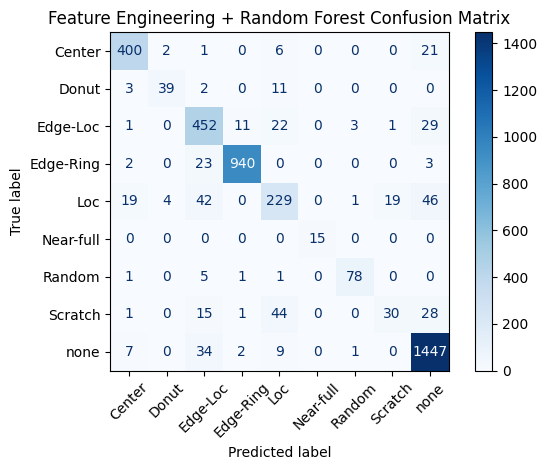

Confusion Matrix 저장 완료: /content/drive/MyDrive/ML Project/WM811K/outputs/feature_engineering_confusion_matrix.png


In [28]:
# ============================================================
# 31. Confusion Matrix 시각화 및 저장
# ============================================================

cm = confusion_matrix(y_test_fe, test_pred)

plt.figure(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    cmap="Blues",
    xticks_rotation=45,
    values_format="d"
)

plt.title("Feature Engineering + Random Forest Confusion Matrix")
plt.tight_layout()
plt.savefig(RF_CM_PATH, dpi=300, bbox_inches="tight")
plt.show()

print("Confusion Matrix 저장 완료:", RF_CM_PATH)

In [29]:
# ============================================================
# 32. Feature Importance 계산 및 저장
# ============================================================

importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
).reset_index(drop=True)

importance_df.to_csv(RF_IMPORTANCE_PATH, index=False)

print("Feature Importance 저장 완료:", RF_IMPORTANCE_PATH)

print()
print("상위 20개 Feature:")
display(importance_df.head(20))

Feature Importance 저장 완료: /content/drive/MyDrive/ML Project/WM811K/outputs/feature_engineering_feature_importance.csv

상위 20개 Feature:


,feature,importance
0,largest_component_ratio,0.093767
1,defect_ratio,0.063056
2,middle_defect_ratio,0.062397
3,edge_defect_ratio,0.056379
4,distance_from_center_std,0.055483
5,middle_defect_share,0.055159
6,bbox_fill_ratio,0.053854
7,distance_from_center_mean,0.048212
8,defect_count,0.042903
9,center_defect_ratio,0.042025


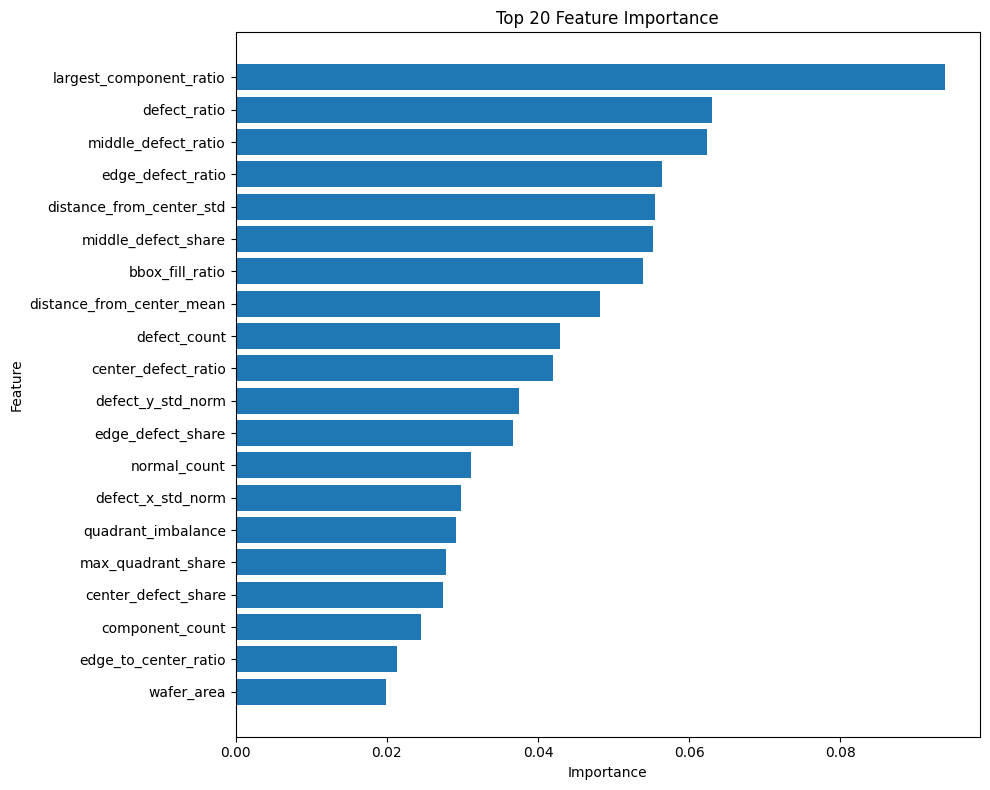

In [30]:
# ============================================================
# 33. Feature Importance 시각화
# ============================================================

top_n = 20

top_importance = importance_df.head(top_n)

plt.figure(figsize=(10, 8))
plt.barh(top_importance["feature"][::-1], top_importance["importance"][::-1])
plt.title("Top 20 Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [31]:
# ============================================================
# 34. Random Forest 모델 저장
# ============================================================

joblib.dump(rf_model, RF_MODEL_PATH)

print("Random Forest 모델 저장 완료:", RF_MODEL_PATH)

Random Forest 모델 저장 완료: /content/drive/MyDrive/ML Project/WM811K/outputs/feature_engineering_random_forest.pkl


In [34]:
# ============================================================
# 35. CNN 결과와 비교용 표 생성
# ============================================================

cnn_accuracy = 0.9099
cnn_balanced_accuracy = 0.8845
cnn_macro_f1 = 0.8663

comparison_df = pd.DataFrame({
    "model": [
        "Light CNN",
        "Feature Engineering + Random Forest"
    ],
    "input_type": [
        "64 x 64 wafer map image",
        "handcrafted wafer map features"
    ],
    "accuracy": [
        cnn_accuracy,
        test_accuracy
    ],
    "balanced_accuracy": [
        cnn_balanced_accuracy,
        test_balanced_accuracy
    ],
    "macro_f1": [
        cnn_macro_f1,
        test_macro_f1
    ]
})

COMPARISON_PATH = os.path.join(OUTPUT_DIR, "cnn_vs_feature_engineering_comparison.csv")

comparison_df.to_csv(COMPARISON_PATH, index=False)

print("CNN vs Feature Engineering 비교표 저장 완료:", COMPARISON_PATH)

display(comparison_df)

CNN vs Feature Engineering 비교표 저장 완료: /content/drive/MyDrive/ML Project/WM811K/outputs/cnn_vs_feature_engineering_comparison.csv


,model,input_type,accuracy,balanced_accuracy,macro_f1
0,Light CNN,64 x 64 wafer map image,0.909900,0.884500,0.866300
1,Feature Engineering + Random Forest,handcrafted wafer map features,0.895854,0.804573,0.822417
